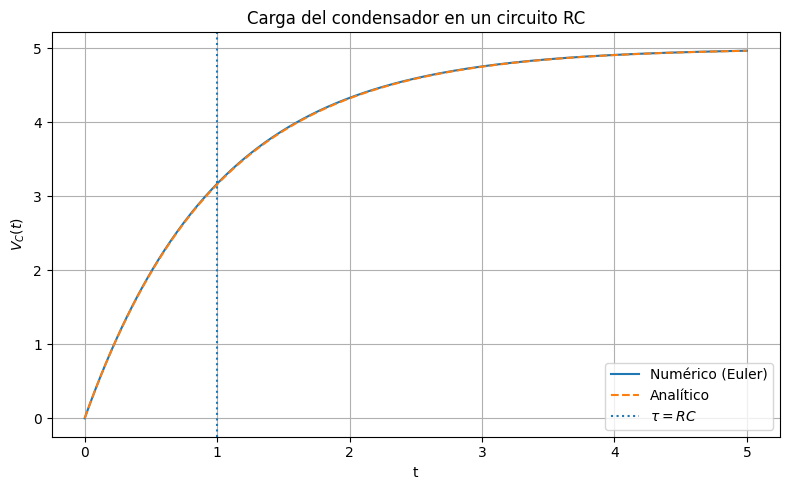

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

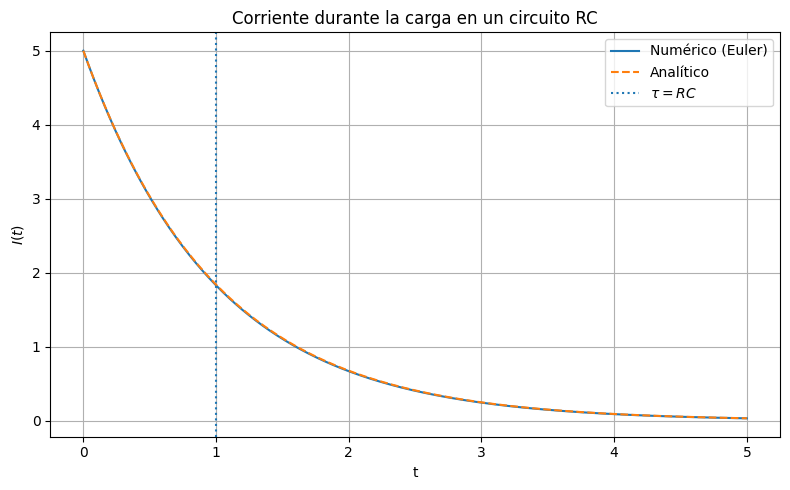

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

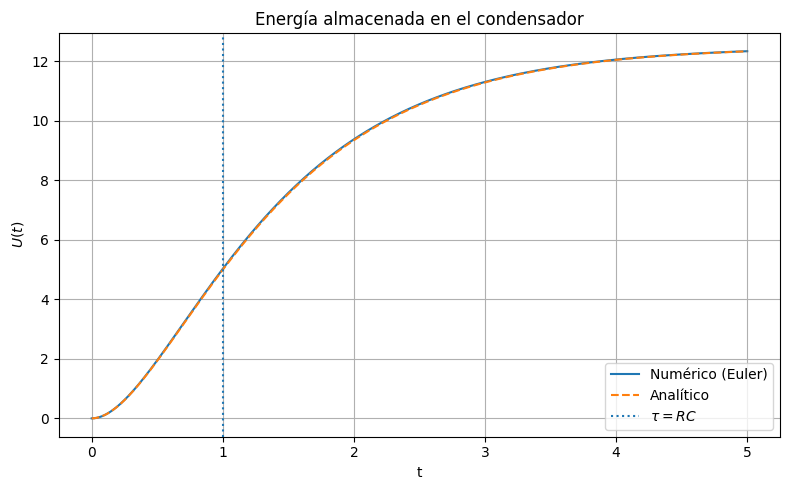

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

CIRCUITO RC: CARGA
R = 1.0
C = 1.0
V0 = 5.0
tau = RC = 1.0
Vc(tau) analítico = 3.1606 V
I(0) = 5.0000 A
Energía final = 12.5000 J


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# =====================================================
# CIRCUITO RC: CARGA DEL CONDENSADOR
# =====================================================

# Parámetros físicos
R = 1.0
C = 1.0
V0 = 5.0

tau = R * C

# Tiempo de simulación
t_max = 5.0 * tau
dt = 0.01
t = np.arange(0, t_max + dt, dt)

# Arreglos numéricos
Vc_num = np.zeros_like(t)
I_num = np.zeros_like(t)
U_num = np.zeros_like(t)

# Condición inicial
Vc_num[0] = 0.0

# Método de Euler
for n in range(len(t) - 1):
    dVc_dt = (V0 - Vc_num[n]) / (R * C)
    Vc_num[n + 1] = Vc_num[n] + dt * dVc_dt

# Corriente y energía
for n in range(len(t)):
    I_num[n] = (V0 - Vc_num[n]) / R
    U_num[n] = 0.5 * C * Vc_num[n]**2

# Solución analítica
Vc_ana = V0 * (1.0 - np.exp(-t / tau))
I_ana = (V0 / R) * np.exp(-t / tau)
U_ana = 0.5 * C * Vc_ana**2

# -----------------------------------------------------
# Gráfica 1: voltaje
# -----------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(t, Vc_num, label='Numérico (Euler)')
plt.plot(t, Vc_ana, '--', label='Analítico')
plt.axvline(tau, linestyle=':', label=r'$\tau=RC$')
plt.xlabel('t')
plt.ylabel(r'$V_C(t)$')
plt.title('Carga del condensador en un circuito RC')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("RC_Carga_Voltaje.pdf", dpi=300, bbox_inches="tight")
plt.show()
files.download("RC_Carga_Voltaje.pdf")

# -----------------------------------------------------
# Gráfica 2: corriente
# -----------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(t, I_num, label='Numérico (Euler)')
plt.plot(t, I_ana, '--', label='Analítico')
plt.axvline(tau, linestyle=':', label=r'$\tau=RC$')
plt.xlabel('t')
plt.ylabel(r'$I(t)$')
plt.title('Corriente durante la carga en un circuito RC')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("RC_Carga_Corriente.pdf", dpi=300, bbox_inches="tight")
plt.show()
files.download("RC_Carga_Corriente.pdf")

# -----------------------------------------------------
# Gráfica 3: energía
# -----------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(t, U_num, label='Numérico (Euler)')
plt.plot(t, U_ana, '--', label='Analítico')
plt.axvline(tau, linestyle=':', label=r'$\tau=RC$')
plt.xlabel('t')
plt.ylabel(r'$U(t)$')
plt.title('Energía almacenada en el condensador')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("RC_Carga_Energia.pdf", dpi=300, bbox_inches="tight")
plt.show()
files.download("RC_Carga_Energia.pdf")

print("===================================")
print("CIRCUITO RC: CARGA")
print("===================================")
print(f"R = {R}")
print(f"C = {C}")
print(f"V0 = {V0}")
print(f"tau = RC = {tau}")
print(f"Vc(tau) analítico = {V0 * (1 - np.exp(-1)):.4f} V")
print(f"I(0) = {V0/R:.4f} A")
print(f"Energía final = {0.5 * C * V0**2:.4f} J")